# 🐋 Whale Liquidity Indicator Visualization

This notebook imports and plots the `whale_liquidity.py` indicator directly.

No logic is duplicated - we use the exact same function from `user_data/indicators/whale_liquidity.py`

In [17]:
# Setup: Add project root to path
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/xyd945/Github/first-duck-trade


In [18]:
# Import the ACTUAL indicator - no duplication!
from user_data.indicators.whale_liquidity import add_whale_liquidity

import pandas as pd
import matplotlib.pyplot as plt

print("✅ Imports successful!")

✅ Imports successful!


In [19]:
# Configuration
PAIR = "BTC_USDT_USDT"  # Format: BTC_USDT_USDT (underscores)
TIMEFRAME = "4h"
LAST_N_CANDLES = 2190  # Show last N candles (0 = all)

# Indicator parameters (same as in whale_liquidity.py defaults)
SMOOTH_LEN = 40
SPIKE_THRESHOLD = 3.0

In [20]:
# Load OHLCV data
data_path = PROJECT_ROOT / "user_data" / "data" / "okx" / "futures" / f"{PAIR}-{TIMEFRAME}-futures.feather"

df = pd.read_feather(data_path)
print(f"Loaded {len(df)} candles")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
df.tail(3)

Loaded 2192 candles
Date range: 2025-01-19 00:00:00+00:00 → 2026-01-19 04:00:00+00:00


,date,open,high,low,close,volume
2189,2026-01-18 20:00:00+00:00,95326.1,95495.0,93555.0,93625.2,11471.0808
2190,2026-01-19 00:00:00+00:00,93625.1,93625.2,91816.7,92637.7,26232.7550
2191,2026-01-19 04:00:00+00:00,92637.7,92805.6,92344.0,92781.0,5482.0952


In [21]:
# Apply the indicator (directly from whale_liquidity.py!)
df = add_whale_liquidity(df, smooth_len=SMOOTH_LEN, spike_threshold=SPIKE_THRESHOLD)

# Show the new columns
print("New columns added:")
print([c for c in df.columns if c in ['raw_delta', 'liq_wave', 'wave_std', 'is_whale_buy', 'is_whale_sell', 'whale_signal']])

# Limit to last N candles for plotting
if LAST_N_CANDLES > 0:
    df = df.tail(LAST_N_CANDLES).copy()
    df = df.reset_index(drop=True)
    print(f"\nShowing last {LAST_N_CANDLES} candles")

New columns added:
['raw_delta', 'liq_wave', 'wave_std', 'is_whale_buy', 'is_whale_sell', 'whale_signal']

Showing last 2190 candles


In [22]:
# Statistics
print("="*50)
print("📊 INDICATOR STATISTICS")
print("="*50)

whale_buys = df['is_whale_buy'].sum()
whale_sells = df['is_whale_sell'].sum()

print(f"Total Candles: {len(df)}")
print(f"Whale Buy Signals: {whale_buys} ({whale_buys/len(df)*100:.2f}%)")
print(f"Whale Sell Signals: {whale_sells} ({whale_sells/len(df)*100:.2f}%)")
print(f"\nLiq Wave Range: [{df['liq_wave'].min():.2f}, {df['liq_wave'].max():.2f}]")

📊 INDICATOR STATISTICS
Total Candles: 2190
Whale Buy Signals: 27 (1.23%)
Whale Sell Signals: 6 (0.27%)

Liq Wave Range: [-13407.73, 18379.60]


/var/folders/zt/26nszyg15sxf7_gmph880f1h0000gn/T/ipykernel_16927/3688958933.py:41: UserWarning: Glyph 128011 (\N{WHALE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/xyd945/dev/miniconda3/envs/freqtrade/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128011 (\N{WHALE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


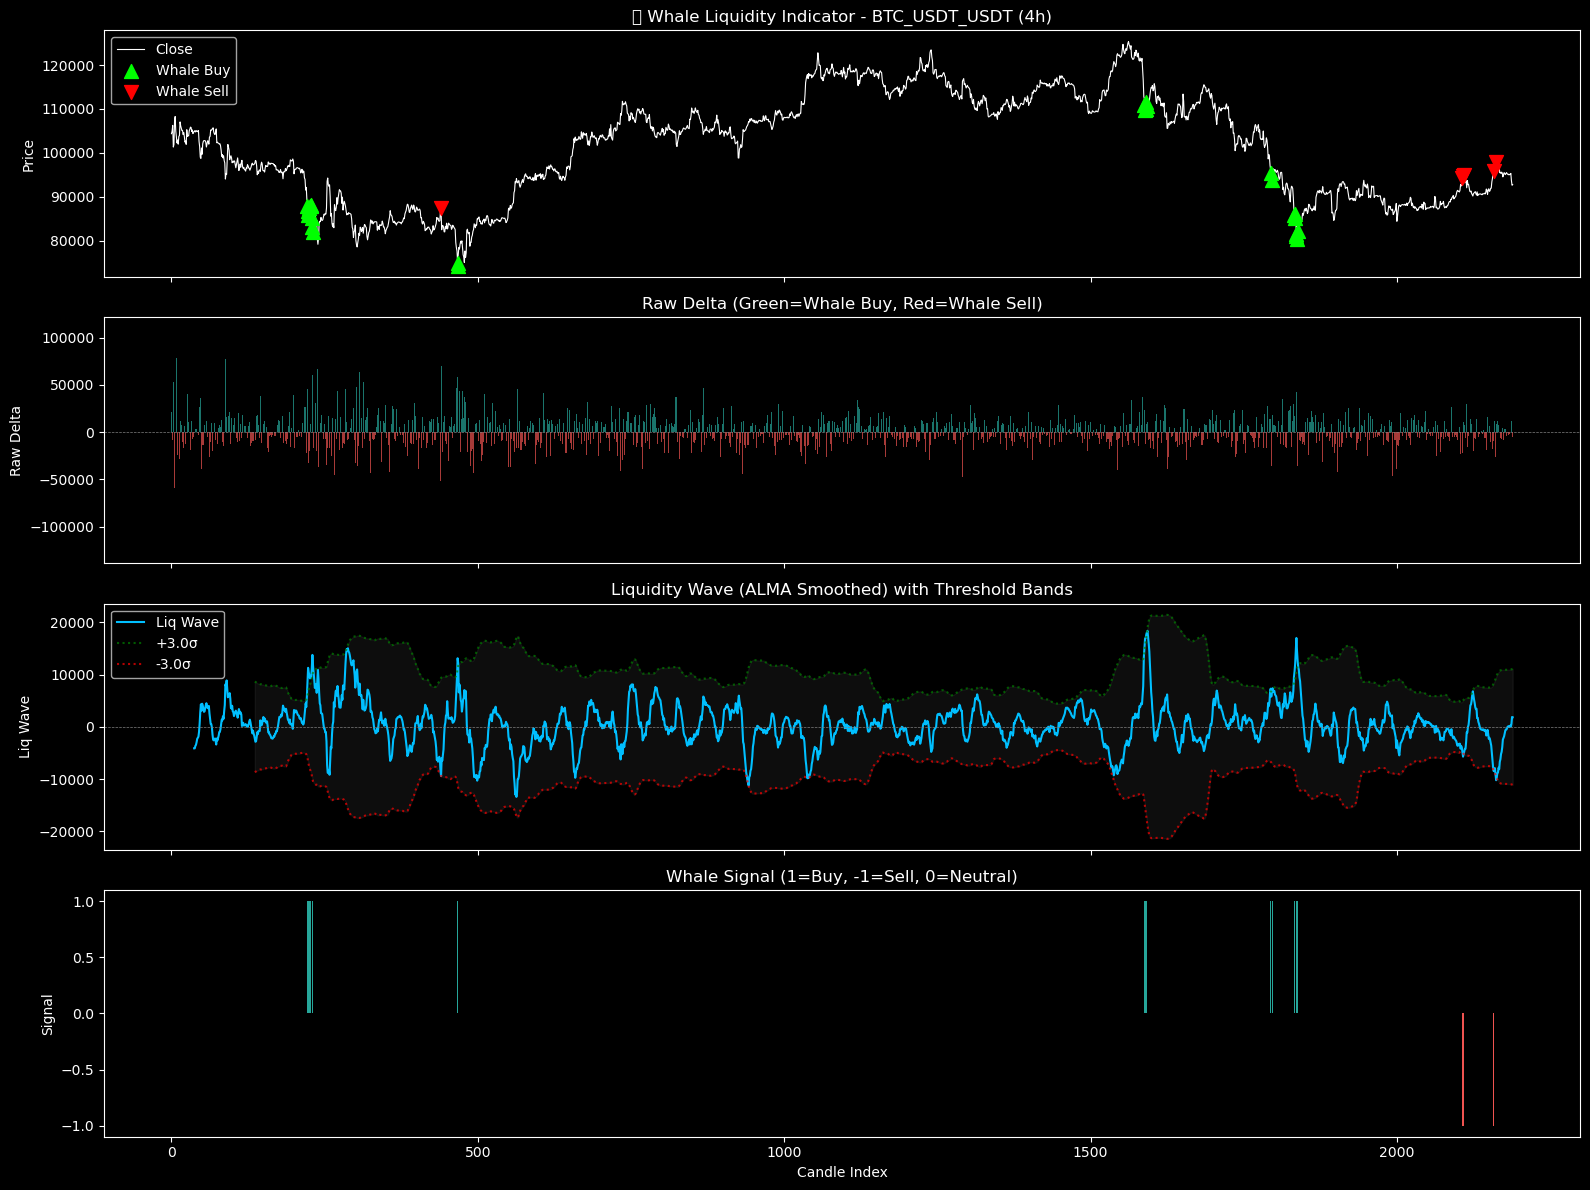

In [23]:
# Plot!
plt.style.use('dark_background')
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# 1. Price with whale signals
axes[0].plot(df.index, df['close'], color='white', linewidth=0.8, label='Close')
whale_buy_idx = df[df['is_whale_buy']].index
whale_sell_idx = df[df['is_whale_sell']].index
axes[0].scatter(whale_buy_idx, df.loc[whale_buy_idx, 'low'] * 0.998, 
                marker='^', color='lime', s=100, label='Whale Buy', zorder=5)
axes[0].scatter(whale_sell_idx, df.loc[whale_sell_idx, 'high'] * 1.002, 
                marker='v', color='red', s=100, label='Whale Sell', zorder=5)
axes[0].set_ylabel('Price')
axes[0].set_title(f'🐋 Whale Liquidity Indicator - {PAIR} ({TIMEFRAME})')
axes[0].legend(loc='upper left')

# 2. Raw Delta
colors = ['#26a69a' if x > 0 else '#ef5350' for x in df['raw_delta']]
axes[1].bar(df.index, df['raw_delta'], color=colors, alpha=0.7)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[1].set_ylabel('Raw Delta')
axes[1].set_title('Raw Delta (Green=Whale Buy, Red=Whale Sell)')

# 3. Liquidity Wave with thresholds
axes[2].plot(df.index, df['liq_wave'], color='#00BFFF', linewidth=1.5, label='Liq Wave')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.5)
axes[2].plot(df.index, df['wave_std'] * SPIKE_THRESHOLD, color='green', linestyle=':', alpha=0.7, label=f'+{SPIKE_THRESHOLD}σ')
axes[2].plot(df.index, -df['wave_std'] * SPIKE_THRESHOLD, color='red', linestyle=':', alpha=0.7, label=f'-{SPIKE_THRESHOLD}σ')
axes[2].fill_between(df.index, df['wave_std'] * SPIKE_THRESHOLD, -df['wave_std'] * SPIKE_THRESHOLD, alpha=0.1, color='gray')
axes[2].set_ylabel('Liq Wave')
axes[2].set_title('Liquidity Wave (ALMA Smoothed) with Threshold Bands')
axes[2].legend(loc='upper left')

# 4. Whale Signals
signal_colors = ['#26a69a' if x > 0 else '#ef5350' if x < 0 else '#333333' for x in df['whale_signal']]
axes[3].bar(df.index, df['whale_signal'], color=signal_colors)
axes[3].set_ylabel('Signal')
axes[3].set_xlabel('Candle Index')
axes[3].set_title('Whale Signal (1=Buy, -1=Sell, 0=Neutral)')

plt.tight_layout()
plt.show()

In [24]:
# Show recent whale signals with dates
print("\n📅 Recent Whale Signals:")
signals = df[df['whale_signal'] != 0][['date', 'close', 'liq_wave', 'whale_signal']].tail(10)
signals['type'] = signals['whale_signal'].map({1: '🟢 BUY', -1: '🔴 SELL'})
signals


📅 Recent Whale Signals:


,date,close,liq_wave,whale_signal,type
1834,2025-11-21 00:00:00+00:00,85790.2,12070.608038,1,🟢 BUY
1835,2025-11-21 04:00:00+00:00,84000.1,14592.946011,1,🟢 BUY
1836,2025-11-21 08:00:00+00:00,82285.0,17011.077256,1,🟢 BUY
1837,2025-11-21 12:00:00+00:00,82904.7,14561.661064,1,🟢 BUY
1838,2025-11-21 16:00:00+00:00,84171.8,12676.677073,1,🟢 BUY
2107,2026-01-05 12:00:00+00:00,93909.1,-4904.953103,-1,🔴 SELL
2108,2026-01-05 16:00:00+00:00,94245.0,-5708.442323,-1,🔴 SELL
2109,2026-01-05 20:00:00+00:00,93817.8,-5231.134822,-1,🔴 SELL
2158,2026-01-14 00:00:00+00:00,95671.0,-8468.797571,-1,🔴 SELL
2162,2026-01-14 16:00:00+00:00,97213.3,-10210.853866,-1,🔴 SELL
